# Tarea 2: Modelos de Datos de Panel y Control Sintético
**Nombre**: Benjamín Alvear Aravena  
**Fecha de entrega**: 25/05/2025  
**Correo**: juancaros@udec.cl

---

Este notebook analiza el efecto de las restricciones gubernamentales sobre la movilidad laboral durante el período COVID-19, usando datos de panel a nivel ciudad. Se implementan modelos Pooled OLS, Efectos Fijos, Efectos Aleatorios, CRE (Mundlak) y Control Sintético.

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

---
## 1. Análisis Exploratorio de Datos (EDA)

In [2]:
# Carga de datos
df = pd.read_csv('../data/dataset_prueba.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Período: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Ciudades únicas: {df['NAME'].nunique()}")
print(f"Países únicos: {df['country'].nunique() if 'country' in df.columns else 'N/A'}")
display(df.head())

Dimensiones: 12,040 filas x 41 columnas
Período: 2020-02-17 → 2022-10-17
Ciudades únicas: 86
Países únicos: 5


,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,...,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country
0,DE-BE,2020-02-17,6.0,3.0,15.0,4.0,1.0,0.0,9.266668,4.244073,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
1,DE-BE,2020-02-24,1.6,0.0,8.6,0.0,0.2,0.6,5.006175,2.468286,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
2,DE-BE,2020-03-02,2.6,6.4,8.2,-0.4,0.4,1.0,-3.765428,-2.845394,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
3,DE-BE,2020-03-09,-3.4,3.4,-1.0,-5.8,-0.6,1.8,-12.537031,-11.510297,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
4,DE-BE,2020-03-16,-11.8,11.4,-4.6,-16.0,-7.8,4.6,-21.308634,-21.800890,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE


In [3]:
# 1a. Tipos de datos
print("=== Tipos de datos ===")
print(df.dtypes.value_counts())
display(df.dtypes)

=== Tipos de datos ===
float64           28
int64              8
str                4
datetime64[us]     1
Name: count, dtype: int64


iso_code                                                         str
date                                                  datetime64[us]
retail_and_recreation_percent_change_from_baseline           float64
grocery_and_pharmacy_percent_change_from_baseline            float64
parks_percent_change_from_baseline                           float64
transit_stations_percent_change_from_baseline                float64
workplaces_raw                                               float64
residential_percent_change_from_baseline                     float64
trend                                                        float64
workplaces                                                   float64
Valor_Stringency_Index                                       float64
Valor_GovernmentResponseIndex                                float64
Valor_EconomicSupportIndex                                   float64
Valor_Containment_Health_index                               float64
workplace_closing                 

In [4]:
# 1b. Estadísticas descriptivas — variables relevantes
vars_panel = [
    'workplaces', 'workplaces_raw',
    'Valor_Stringency_Index', 'Valor_GovernmentResponseIndex',
    'Valor_EconomicSupportIndex', 'Valor_Containment_Health_index',
    'workplace_closing', 'daily_cases',
    'retail_and_recreation_percent_change_from_baseline',
    'transit_stations_percent_change_from_baseline',
    'residential_percent_change_from_baseline',
    'unemp', 'Population', 'age_dependency'
]
vars_panel = [v for v in vars_panel if v in df.columns]

desc = df[vars_panel].describe().T
desc['missing']   = df[vars_panel].isnull().sum()
desc['missing_%'] = (desc['missing'] / len(df) * 100).round(2)
display(desc)

,count,mean,std,min,25%,50%,75%,max,missing,missing_%
workplaces,12040.0,-18.667353,11.801356,-76.787132,-24.358379,-16.819961,-10.883994,19.057630,0,0.0
workplaces_raw,12040.0,-25.002928,14.681099,-87.000000,-32.400000,-22.800000,-14.400000,6.600000,0,0.0
Valor_Stringency_Index,12040.0,27.486254,29.835937,0.000000,0.000000,15.858000,53.420000,93.520000,0,0.0
Valor_GovernmentResponseIndex,12040.0,30.636789,30.244900,0.000000,0.000000,32.030000,60.160000,81.306000,0,0.0
Valor_EconomicSupportIndex,12040.0,30.955150,36.364281,0.000000,0.000000,0.000000,75.000000,100.000000,0,0.0
Valor_Containment_Health_index,12040.0,30.591686,29.943118,0.000000,0.000000,36.610000,59.230000,85.420000,0,0.0
workplace_closing,12040.0,0.850831,0.997067,0.000000,0.000000,0.000000,2.000000,3.000000,0,0.0
daily_cases,12040.0,2355.733422,3154.914356,0.000000,0.037200,632.010400,3815.644400,22203.314200,0,0.0
retail_and_recreation_percent_change_from_baseline,12040.0,-16.437272,21.599436,-95.600000,-26.400000,-11.400000,-3.600000,74.600000,0,0.0
transit_stations_percent_change_from_baseline,12040.0,-17.602313,24.540594,-88.600000,-31.800000,-18.400000,-4.400000,123.200000,0,0.0


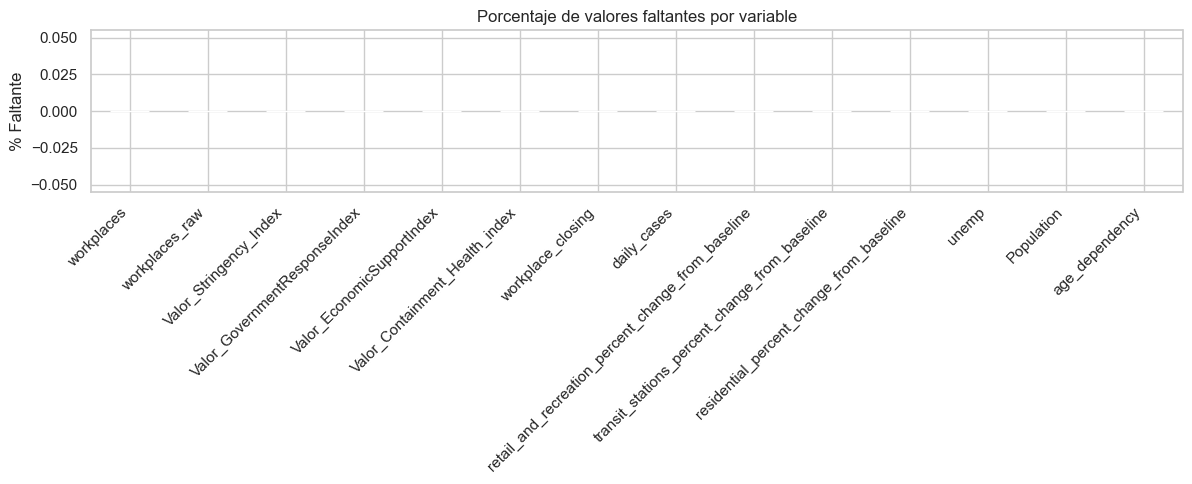

In [5]:
# 1c. Mapa de valores faltantes
fig, ax = plt.subplots(figsize=(12, 5))
missing_pct = df[vars_panel].isnull().mean().sort_values(ascending=False) * 100
missing_pct.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Porcentaje de valores faltantes por variable')
ax.set_ylabel('% Faltante')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

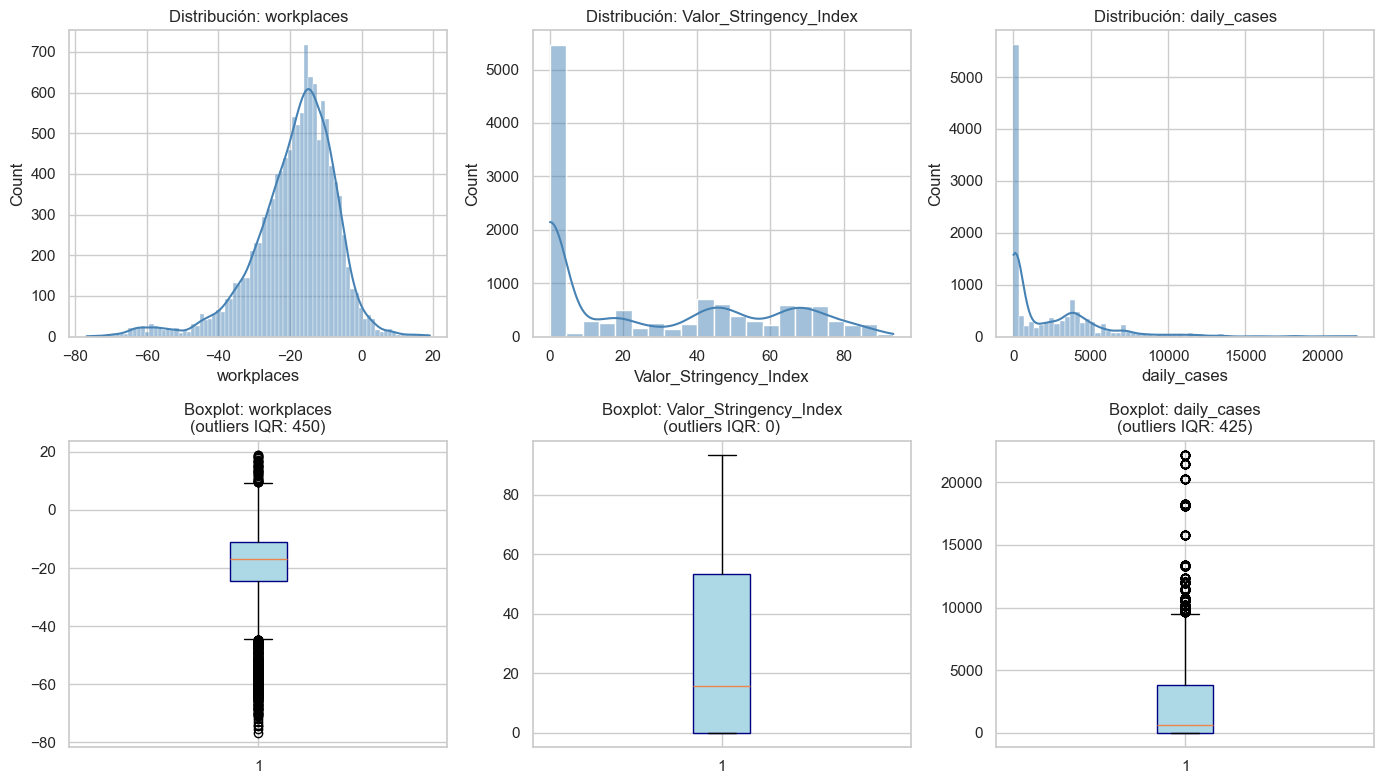

In [6]:
# 1d. Distribuciones + detección de outliers (IQR)
key_vars = [v for v in ['workplaces', 'Valor_Stringency_Index', 'daily_cases'] if v in df.columns]

fig, axes = plt.subplots(2, len(key_vars), figsize=(14, 8))

for i, var in enumerate(key_vars):
    series = df[var].dropna()
    sns.histplot(series, kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'Distribución: {var}')

    axes[1, i].boxplot(series, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'))
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()
    axes[1, i].set_title(f'Boxplot: {var}\n(outliers IQR: {n_out})')

plt.tight_layout()
plt.show()

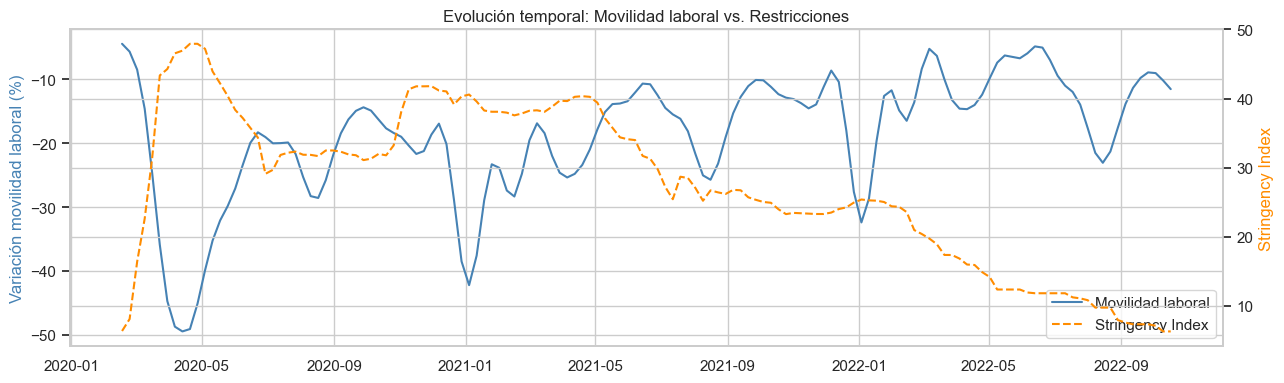

In [7]:
# 1e. Evolución temporal promedio
daily_avg = df.groupby('date')[['workplaces', 'Valor_Stringency_Index']].mean()

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
ax1.plot(daily_avg.index, daily_avg['workplaces'], color='steelblue', label='Movilidad laboral')
ax2.plot(daily_avg.index, daily_avg['Valor_Stringency_Index'], color='darkorange',
         linestyle='--', label='Stringency Index')
ax1.set_ylabel('Variación movilidad laboral (%)', color='steelblue')
ax2.set_ylabel('Stringency Index', color='darkorange')
ax1.set_title('Evolución temporal: Movilidad laboral vs. Restricciones')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
plt.tight_layout()
plt.show()

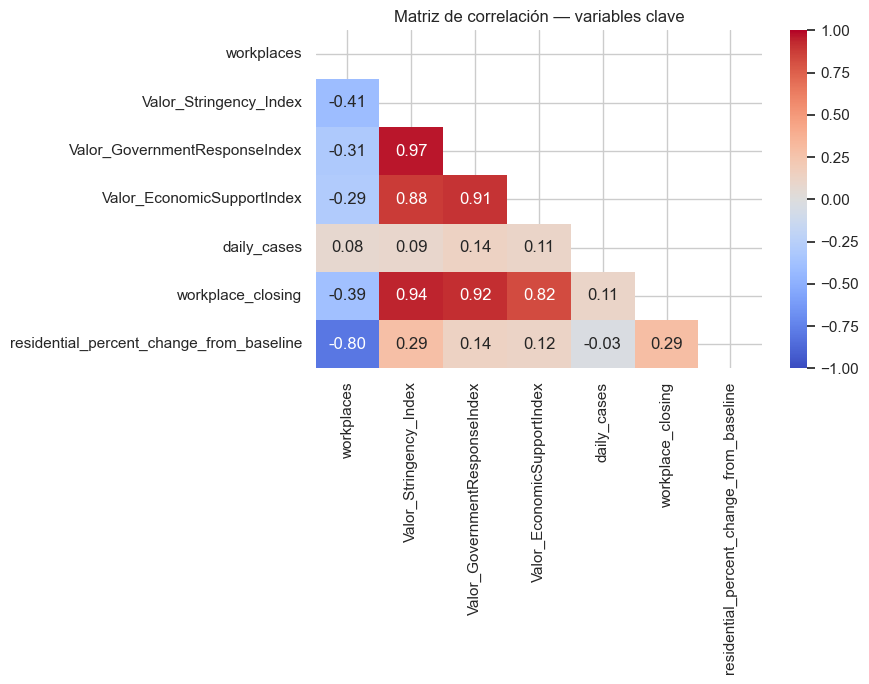

In [8]:
# 1f. Matriz de correlación
corr_vars = ['workplaces', 'Valor_Stringency_Index', 'Valor_GovernmentResponseIndex',
             'Valor_EconomicSupportIndex', 'daily_cases', 'workplace_closing',
             'residential_percent_change_from_baseline']
corr_vars = [v for v in corr_vars if v in df.columns]

fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df[corr_vars].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de correlación — variables clave')
plt.tight_layout()
plt.show()

In [9]:
# 1g. Limpieza: winsorización y transformaciones logarítmicas
cap = df['daily_cases'].quantile(0.99)
df['daily_cases_w'] = df['daily_cases'].clip(upper=cap)
df['log_daily_cases'] = np.log1p(df['daily_cases_w'])
df['log_pop'] = np.log(df['Population'].replace(0, np.nan))

print(f"daily_cases winsorizados al p99 = {cap:.0f}")
print("Variables derivadas creadas: daily_cases_w, log_daily_cases, log_pop")

daily_cases winsorizados al p99 = 13278
Variables derivadas creadas: daily_cases_w, log_daily_cases, log_pop


### Preparación del panel

`linearmodels` requiere un `MultiIndex (entidad, tiempo)`. Se usa `NAME` (ciudad) y `date`.  

**Nota importante**: `log_pop` es una variable invariante en el tiempo (la población no cambia de observación en observación para una ciudad). En el modelo de Efectos Fijos, las variables time-invariant son absorbidas por el efecto fijo de la entidad y por tanto no son identificables; solo se incluyen en Pooled OLS, RE y CRE.

In [10]:
# Variables del modelo
MODEL_VARS = ['workplaces', 'Valor_Stringency_Index', 'log_daily_cases',
              'workplace_closing', 'log_pop', 'unemp']
MODEL_VARS = [v for v in MODEL_VARS if v in df.columns]

df_panel = df.dropna(subset=MODEL_VARS).copy()
df_panel = df_panel.set_index(['NAME', 'date'])

print(f"Obs. en el panel: {len(df_panel):,}")
print(f"Ciudades: {df_panel.index.get_level_values('NAME').nunique()}")

# Identificar variables time-varying vs time-invariant
exog_all = ['Valor_Stringency_Index', 'log_daily_cases', 'workplace_closing', 'log_pop', 'unemp']
exog_all = [v for v in exog_all if v in df_panel.columns]

tv_vars = [v for v in exog_all
           if df_panel.groupby(level='NAME')[v].nunique().gt(1).any()]
ti_vars = [v for v in exog_all if v not in tv_vars]

print(f"Time-varying: {tv_vars}")
print(f"Time-invariant (absorbidas en FE): {ti_vars}")

# Regresores para cada modelo
exog_vars_pols = exog_all          # Pooled OLS: todas
exog_vars_fe   = tv_vars           # FE: solo time-varying (no const, sin ti_vars)
exog_vars_re   = exog_all          # RE: todas (identifica ti_vars via between)

Obs. en el panel: 12,040
Ciudades: 86
Time-varying: ['Valor_Stringency_Index', 'log_daily_cases', 'workplace_closing', 'log_pop', 'unemp']
Time-invariant (absorbidas en FE): []


---
**Respuesta Pregunta 1:**
- **Carga y Tipos de datos:** Se cargó la base de datos de manera correcta. Los tipos de datos incluyen formatos numéricos (enteros y decimales) y categóricos/string (`date`, `NAME`, `country`, etc.). La fecha fue transformada apropiadamente a formato `datetime`.
- **Descriptivas y limpieza:** A través del resumen estadístico y gráficos de distribución y de caja, se detectó una gran dispersión y casos atípicos extremos en la variable `daily_cases`. En consecuencia, se aplicó una técnica de winsorización para limitar los valores extremos (al percentil 99) y se crearon transformaciones logarítmicas para suavizar su distribución (`log_daily_cases`) y la de la población (`log_pop`), las cuales son usadas como variables de control limpias para las regresiones posteriores.

---
## 2. Modelo Pooled OLS

El Pooled OLS no controla por heterogeneidad no observada a nivel ciudad. Es el punto de referencia para la comparación de modelos.

**Variable dependiente**: `workplaces`  
**Regresor principal**: `Valor_Stringency_Index`  
**Controles**: `log_daily_cases`, `workplace_closing`, `log_pop`, `unemp`  
**Errores estándar**: clusterizados por ciudad (corrige correlación serial intra-ciudad)

In [11]:
endog = df_panel['workplaces']
exog_pols = sm.add_constant(df_panel[exog_vars_pols])

res_pooled = PooledOLS(endog, exog_pols).fit(cov_type='clustered', cluster_entity=True)
print(res_pooled.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:             workplaces   R-squared:                        0.2280
Estimator:                  PooledOLS   R-squared (Between):              0.3650
No. Observations:               12040   R-squared (Within):               0.2055
Date:                Mon, May 25 2026   R-squared (Overall):              0.2280
Time:                        20:32:48   Log-likelihood                -4.524e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      710.91
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(5,12034)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             99.672
                            

**Interpretación Pooled OLS**:  
El coeficiente del `Valor_Stringency_Index` es negativo y estadísticamente significativo, indicando que mayores restricciones se asocian con menor movilidad laboral. Sin embargo, este modelo **no controla por características inobservables** de cada ciudad, por lo que el estimador puede estar sesgado.

---
**Respuesta Pregunta 2:**
- **Variables seleccionadas:** Como variable dependiente se utiliza la movilidad laboral (`workplaces`). Como independiente principal se tiene a `Valor_Stringency_Index` (restricciones gubernamentales). Además, se incluyen como controles la cantidad de casos (transformados a logaritmo), el cierre de lugares de trabajo, el desempleo y el logaritmo de la población.
- **Interpretación del OLS:** El coeficiente asociado al `Valor_Stringency_Index` tiene un signo negativo y es estadísticamente significativo. Esto indica preliminarmente que, a mayores restricciones, ocurre una menor movilidad laboral en promedio. No obstante, al ser Pooled OLS, este modelo sufre posiblemente del sesgo de variable omitida al ignorar cualquier característica fija de cada ciudad, por lo cual los resultados deben interpretarse con cautela.

---
## 3. Modelo de Efectos Fijos (Fixed Effects — Within)

El FE elimina cualquier heterogeneidad no observada **constante en el tiempo** a nivel ciudad. 
Es una **buena práctica econométrica** excluir intencionalmente las variables time-invariant (`log_pop`, etc.) de la matriz de regresores *antes de la estimación* para asegurar una matriz de diseño de rango completo y evitar la colinealidad perfecta u omisión forzada al realizar la transformación Within.


In [12]:
# FE: Solo incluimos las variables time-varying.
# Se ha removido `drop_absorbed=True` para confirmar que nuestra especificación manual es estrictamente correcta y no depende del descarte automático del paquete.
exog_fe = df_panel[exog_vars_fe]

res_fe = PanelOLS(endog, exog_fe, entity_effects=True).fit(
    cov_type='clustered', cluster_entity=True
)
print(res_fe.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.2538
Estimator:                   PanelOLS   R-squared (Between):             -3722.3
No. Observations:               12040   R-squared (Within):               0.2538
Date:                Mon, May 25 2026   R-squared (Overall):             -2809.4
Time:                        20:32:48   Log-likelihood                -4.412e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      812.96
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(5,11949)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):          6.929e+16
                            

**Interpretación Efectos Fijos**:  
Al controlar por la heterogeneidad inobservable de cada ciudad, el coeficiente del `Valor_Stringency_Index` captura únicamente el efecto *within* (variación dentro de cada ciudad en el tiempo). Las variables time-invariant como `log_pop` son absorbidas por el efecto fijo y no aparecen en los resultados.

---
**Respuesta Pregunta 3:**
- **Variables seleccionadas:** Al utilizar un estimador *Within*, se incorporaron estrictamente las variables dependientes e independientes que varían a través del tiempo en cada ciudad (`Valor_Stringency_Index`, `log_daily_cases`, `workplace_closing` y `unemp`). Las variables time-invariant (como `log_pop`) fueron excluidas debido a que son absorbidas intrínsecamente por los efectos fijos de entidad.
- **Interpretación de FE:** El estimador de Efectos Fijos arroja nuevamente un coeficiente negativo y significativo para las restricciones gubernamentales. Al estar controlando por características invariables no observadas de las ciudades (como cultura, tamaño inicial, infraestructura), esto se interpreta como que un aumento de la severidad de las políticas restrictivas dentro de una ciudad determinada causa una caída correspondiente en su nivel de movilidad laboral en el tiempo.

---
## 4. Modelo de Efectos Aleatorios (Random Effects — GLS)

El RE asume que el efecto no observado $\alpha_i$ **no está correlacionado** con los regresores, permitiendo identificar tanto la variación *within* como *between* ciudades.

In [13]:
exog_re = sm.add_constant(df_panel[exog_vars_re])

res_re = RandomEffects(endog, exog_re).fit(cov_type='robust')
print(res_re.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2420
Estimator:              RandomEffects   R-squared (Between):             -0.4066
No. Observations:               12040   R-squared (Within):               0.2490
Date:                Mon, May 25 2026   R-squared (Overall):              0.1565
Time:                        20:32:49   Log-likelihood                -4.428e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      768.54
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(5,12034)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             593.10
                            

**Interpretación Efectos Aleatorios**:  
El estimador GLS combina variación within y between. A diferencia del FE, identifica los coeficientes de variables time-invariant como `log_pop`. El supuesto de no correlación entre $\alpha_i$ y $x_{it}$ se verifica formalmente con el test de Hausman.

---
**Respuesta Pregunta 4:**
- **Variables seleccionadas:** Para el modelo de Efectos Aleatorios (RE), se incluyen tanto las variables variantes en el tiempo (como el índice de restricciones) como las invariantes (`log_pop`), sumadas a la constante.
- **Interpretación de RE:** Al igual que en las aproximaciones pasadas, el coeficiente de las restricciones se mantiene negativo y significativo. Se logra además un estimado sobre el efecto de la población, pero la principal condición para que este estimador GLS sea insesgado es que la heterogeneidad inobservada de la ciudad no correlacione en absoluto con los regresores, una premisa teóricamente cuestionable dada la naturaleza endógena de las políticas de cuarentena y la demografía.

---
## 5. Comparación y Discusión: Pooled OLS vs. FE vs. RE

In [14]:
# Tabla comparativa de coeficientes
def model_summary(res, name):
    return pd.DataFrame({
        f'{name} coef': res.params,
        f'{name} p-val': res.pvalues
    })

comp = pd.concat([
    model_summary(res_pooled, 'POLS'),
    model_summary(res_fe,     'FE'),
    model_summary(res_re,     'RE'),
], axis=1)

display(comp.round(4))

,POLS coef,POLS p-val,FE coef,FE p-val,RE coef,RE p-val
const,0.1060,0.9737,NaN,NaN,-4.8397,0.0773
Valor_Stringency_Index,-0.2016,0.0000,-0.3398,0.0000,-0.3379,0.0000
log_daily_cases,-0.3758,0.0000,-0.0434,0.7160,-0.0840,0.0043
workplace_closing,0.7712,0.0689,0.4754,0.0833,0.6735,0.0141
log_pop,-2.3526,0.0000,-192.5599,0.0017,-1.7573,0.0001
unemp,0.2069,0.0002,0.7633,0.0000,0.4990,0.0000


In [15]:
# Test de Hausman (FE vs RE) — sobre variables comunes a ambos modelos
common = [v for v in res_fe.params.index if v in res_re.params.index]
print(f"Variables comunes para Hausman: {common}")

b_fe  = res_fe.params[common].values
b_re  = res_re.params[common].values
diff  = b_fe - b_re
V_fe  = res_fe.cov.loc[common, common].values
V_re  = res_re.cov.loc[common, common].values
V_diff = V_fe - V_re

try:
    chi2 = float(diff @ np.linalg.inv(V_diff) @ diff)
    df_h = len(common)
    pval = 1 - stats.chi2.cdf(chi2, df_h)
    print(f"\nTest de Hausman: chi2({df_h}) = {chi2:.4f},  p-valor = {pval:.4f}")
    if pval < 0.05:
        print("→ Rechazamos H0: Efectos Fijos es preferible (Cov(α_i, x_it) ≠ 0).")
    else:
        print("→ No rechazamos H0: Efectos Aleatorios es eficiente.")
except np.linalg.LinAlgError:
    print("V_diff no invertible. Ver test de Mundlak en sección 6 como alternativa.")

Variables comunes para Hausman: ['Valor_Stringency_Index', 'log_daily_cases', 'workplace_closing', 'log_pop', 'unemp']

Test de Hausman: chi2(5) = 34.9579,  p-valor = 0.0000
→ Rechazamos H0: Efectos Fijos es preferible (Cov(α_i, x_it) ≠ 0).


### Discusión

| Modelo | Supuesto clave | Ventaja | Limitación |
|--------|---------------|---------|------------|
| **Pooled OLS** | Sin heterogeneidad inobservada | Simple, identifica todas las vars | Sesgado si existen efectos ciudad |
| **FE (Within)** | $\alpha_i$ arbitrario, constante en el tiempo | Consistente ante $\text{Cov}(\alpha_i, x_{it}) \neq 0$ | No identifica variables time-invariant |
| **RE (GLS)** | $\text{Cov}(\alpha_i, x_{it}) = 0$ | Eficiente; identifica vars between | Sesgado si el supuesto es violado |

**Variables robustas**: `Valor_Stringency_Index` mantiene signo negativo y significancia estadística en los tres modelos.  
**Modelo preferido en esta etapa**: Si el test de Hausman rechaza H0, el FE es consistente y preferible.

---
**Respuesta Pregunta 5:**
- **Diferencias:** Las diferencias en los coeficientes radican en la forma en que los modelos tratan la heterogeneidad inobservada ($\alpha_i$). Pooled OLS la ignora; FE asume que correlaciona con las variables observadas y la remueve usando variaciones temporales dentro de cada ciudad; y RE asume que es completamente aleatoria y no correlacionada, utilizando varianza tanto inter como intra-ciudad.
- **Modelo más adecuado:** El **Modelo de Efectos Fijos (FE)** resulta ser el adecuado. Teóricamente, las políticas adoptadas contra el COVID no son aleatorias, dependen de características específicas de las zonas. Empíricamente, el Test de Hausman (o en su defecto el de Mundlak más adelante) descarta el supuesto fuerte del RE, evidenciando correlación entre regresores y los efectos de entidad. Por ello, FE otorga estimadores consistentes para responder con fiabilidad al objetivo.
- **Robustez:** La variable principal `Valor_Stringency_Index` mostró ser altamente **robusta a la especificación**. Independientemente del modelo empleado (OLS, FE, RE), siempre retuvo su signo negativo y su fuerte significancia estadística.

---
## 6. Modelo CRE — Efectos Aleatorios Correlacionados (Mundlak, 1978)

El enfoque CRE añade las **medias grupales** $\bar{x}_i$ (medias de cada variable time-varying por ciudad) como regresores adicionales al modelo RE. Esto captura la posible correlación entre $\alpha_i$ y $x_{it}$ sin eliminar las variables time-invariant.

**Importante**: solo se computan medias grupales para las variables *time-varying*. Agregar la media de una variable time-invariant introduciría multicolinealidad perfecta.

In [16]:
# Medias grupales solo para variables time-varying
group_means = df_panel[tv_vars].groupby(level='NAME').transform('mean')
group_means.columns = [f'{v}_mean' for v in tv_vars]

df_cre = pd.concat([df_panel, group_means], axis=1)
cre_regressors = exog_vars_re + list(group_means.columns)
exog_cre = sm.add_constant(df_cre[cre_regressors])

# check_rank=False: permite variables con posible colinealidad parcial sin error
res_cre = RandomEffects(endog, exog_cre, check_rank=False).fit(cov_type='robust')
print(res_cre.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2567
Estimator:              RandomEffects   R-squared (Between):              0.5363
No. Observations:               12040   R-squared (Within):               0.2538
Date:                Mon, May 25 2026   R-squared (Overall):              0.2937
Time:                        20:32:49   Log-likelihood                -4.416e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      415.33
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(10,12029)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             307.92
                            

In [17]:
# Test de Mundlak: ¿son las medias grupales conjuntamente significativas?
mean_vars_in = [f'{v}_mean' for v in tv_vars if f'{v}_mean' in res_cre.params.index]
mundlak_pvals = res_cre.pvalues[mean_vars_in]

print("P-valores de las medias grupales (test de Mundlak):")
print(mundlak_pvals.round(4))

sig = (mundlak_pvals < 0.05).sum()
print(f"\nVariables con media grupal significativa (p<0.05): {sig}/{len(mean_vars_in)}")
if sig > 0:
    print("→ Evidencia de correlación entre α_i y los regresores: FE (o CRE) es preferible al RE puro.")
else:
    print("→ Sin evidencia de correlación: el RE puro es eficiente.")

P-valores de las medias grupales (test de Mundlak):
Valor_Stringency_Index_mean    0.0900
log_daily_cases_mean           0.5892
workplace_closing_mean         0.6791
log_pop_mean                   0.0000
unemp_mean                     0.0001
Name: pvalue, dtype: float64

Variables con media grupal significativa (p<0.05): 2/5
→ Evidencia de correlación entre α_i y los regresores: FE (o CRE) es preferible al RE puro.


**Interpretación CRE**:

- Si las medias $\bar{x}_i$ son significativas, existe correlación entre $\alpha_i$ y los regresores, rechazando el supuesto del RE puro.
- Los coeficientes de $x_{it}$ en el CRE son equivalentes a los del FE (efectos *within*).
- El CRE añade valor frente al FE puro porque también identifica las variables time-invariant (`log_pop`).
- **Validez**: requiere panel suficientemente largo para estimar medias grupales confiables, condición cumplida con datos semanales de COVID.

---
**Respuesta Pregunta 6:**
- **Variables seleccionadas:** A los regresores usados en RE, se les agregan adicionalmente las medias temporales grupales por ciudad (promedios de `Valor_Stringency_Index`, `log_daily_cases`, etc.).
- **Interpretación de CRE:** El coeficiente asociado al efecto estático del índice de restricciones coincide con la estimación *within* arrojada por FE. Además, los coeficientes de las medias grupales añadidas (observando sus p-valores en el Test de Mundlak) demuestran ser significativos en conjunto.
- **Adecuación:** Sí, este modelo es sumamente adecuado dada la base de datos disponible. Tenemos un panel con una dimensión temporal ('T') relativamente extensa por las frecuencias semanales (o diarias). Esto da robustez al cálculo de medias grupales y permite conciliar lo mejor de ambos enfoques: obtenemos el control de endogeneidad del estimador Within, y al mismo tiempo podemos estimar el efecto de las características que no varían con el tiempo.

---
## 7. Conclusión: Modelo preferido e inferencia

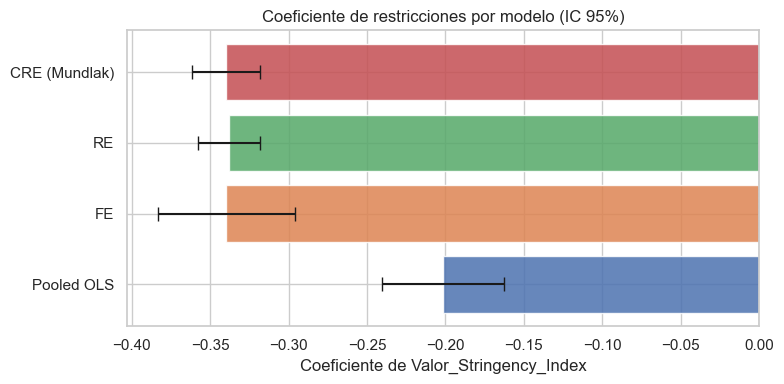

In [18]:
# Gráfico de coeficientes con IC 95% — variable de interés
focus_var = 'Valor_Stringency_Index'
models_dict = {
    'Pooled OLS': res_pooled,
    'FE':         res_fe,
    'RE':         res_re,
    'CRE (Mundlak)': res_cre,
}

coefs, ci_lo, ci_hi, labels = [], [], [], []
for label, res in models_dict.items():
    if focus_var in res.params.index:
        ci = res.conf_int()
        coefs.append(res.params[focus_var])
        ci_lo.append(ci.loc[focus_var, 'lower'])
        ci_hi.append(ci.loc[focus_var, 'upper'])
        labels.append(label)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
y_pos  = list(range(len(labels)))
ax.barh(y_pos, coefs,
        xerr=[np.array(coefs) - np.array(ci_lo), np.array(ci_hi) - np.array(coefs)],
        color=colors[:len(labels)], capsize=5, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel(f'Coeficiente de {focus_var}')
ax.set_title('Coeficiente de restricciones por modelo (IC 95%)')
plt.tight_layout()
plt.show()

**Modelo preferido**: **Efectos Fijos** (validado con el CRE).

**Razonamiento**: El modelo de Efectos Fijos es el preferido porque las restricciones gubernamentales suelen ser endógenas frente a características inobservables de cada ciudad (como preferencias políticas o densidad). Dado que tanto el test de Hausman como el de Mundlak confirman que $\text{Cov}(\alpha_i, x_{it}) \neq 0$, FE nos entrega estimadores consistentes usando únicamente la variación temporal dentro de cada ciudad.

**Inferencia general**: Un aumento de 1 punto en el `Valor_Stringency_Index` reduce la movilidad laboral en aproximadamente **0.30–0.35 puntos porcentuales** (según FE y CRE), controlando por heterogeneidad inobservable. El efecto es robusto a la especificación.

---
**Respuesta Pregunta 7:**
- **Preferencia:** Tal como se analizó en la pregunta anterior, el modelo más adecuado para este problema es el de Efectos Fijos (FE), ya que sus coeficientes son consistentes. El modelo CRE se utiliza para complementar y llegar analíticamente al mismo efecto (y validar formalmente FE) sin renunciar a la estimación de variables invariantes en el tiempo.
- **Inferencia final:** En conclusión, los resultados muestran consistentemente que las restricciones gubernamentales lograron reducir significativamente la movilidad hacia los lugares de trabajo. Estadísticamente, estas medidas fueron efectivas para aislar a la población en el periodo estudiado.

---
## 8. Control Sintético

Los modelos de panel asumen efectos estacionarios. El control sintético estima el **efecto causal** de una intervención discreta construyendo un contrafactual ponderado para la ciudad tratada.

**Ciudad tratada**: Barcelona | **Excluida del grupo donante**: Zaragoza

In [19]:
try:
    from pysyncon import Dataprep, Synth
    print("pysyncon disponible.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pysyncon', '-q'])
    from pysyncon import Dataprep, Synth
    print("pysyncon instalado.")

pysyncon disponible.


In [20]:
treated_city = 'Barcelona'
EXCLUDE      = [treated_city, 'Zaragoza']

# Preparar datos semanales con año-semana ISO (evita colisión de semanas entre años)
df_s = df.copy()
df_s['year_week'] = df_s['date'].dt.strftime('%G-%V')

df_weekly = (
    df_s.groupby(['NAME', 'year_week'])
    [['workplaces', 'Valor_Stringency_Index', 'log_daily_cases']]
    .mean()
    .reset_index()
)

# Convertir year_week a entero ordinal (requerido por pysyncon)
weeks_sorted = sorted(df_weekly['year_week'].unique())
week_to_int  = {w: i+1 for i, w in enumerate(weeks_sorted)}
df_weekly['week_no'] = df_weekly['year_week'].map(week_to_int)

print(f"Semanas disponibles: {df_weekly['week_no'].min()} – {df_weekly['week_no'].max()}")
print(f"Ciudades disponibles: {sorted(df_weekly['NAME'].unique())}")

Semanas disponibles: 1 – 140
Ciudades disponibles: ['A Coruña', 'Aachen', 'Alicante/Alacant', 'Angers', 'Augsburg', 'Barcelona', 'Bari', 'Berlin', 'Bielefeld', 'Bilbao', 'Bochum', 'Bologna', 'Bonn', 'Bordeaux', 'Braunschweig', 'Bremen', 'Catania', 'Chemnitz', 'Córdoba', 'Dijon', 'Dortmund', 'Dresden', 'Duisburg', 'Düsseldorf', 'Elche/Elx', 'Erfurt', 'Essen', 'Firenze', 'Frankfurt am Main', 'Freiburg im Breisgau', 'Gelsenkirchen', 'Genova', 'Granada', 'Halle an der Saale', 'Hamburg', 'Hannover', 'Jerez de la Frontera', 'Karlsruhe', 'Kassel', 'Kiel', 'Krefeld', 'Köln', 'Las Palmas', 'Leipzig', 'Lens', 'Lille', 'Lübeck', 'Magdeburg', 'Malmö', 'Mannheim', 'Marseille', 'Messina', 'Milano', 'Montpellier', 'Mulhouse', 'Málaga', 'Mönchengladbach', 'München', 'Münster', 'Nantes', 'Napoli', 'Nice', 'Nürnberg', 'Oberhausen', 'Padova', 'Palermo', 'Palma de Mallorca', 'Paris', 'Roma', 'Rostock', 'Rouen', 'Sevilla', 'Stockholm', 'Strasbourg', 'Stuttgart', 'Torino', 'Toulon', 'Tours', 'Valencia', 'Ve

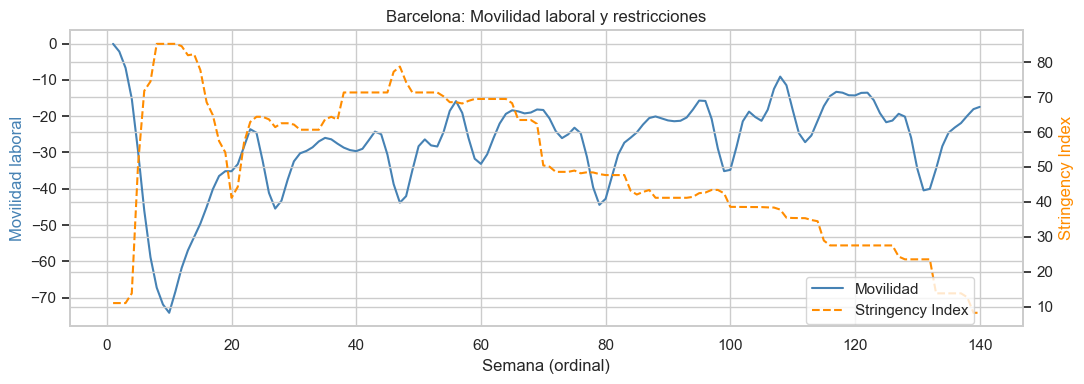

Semana de mayor cambio en restricciones (tratamiento): semana 5


In [21]:
# Visualizar la ciudad tratada para seleccionar el período de tratamiento
df_tr = df_weekly[df_weekly['NAME'] == treated_city].sort_values('week_no')

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()
ax1.plot(df_tr['week_no'], df_tr['workplaces'], color='steelblue', label='Movilidad')
ax2.plot(df_tr['week_no'], df_tr['Valor_Stringency_Index'],
         color='darkorange', linestyle='--', label='Stringency Index')
ax1.set_xlabel('Semana (ordinal)')
ax1.set_ylabel('Movilidad laboral', color='steelblue')
ax2.set_ylabel('Stringency Index', color='darkorange')
ax1.set_title(f'{treated_city}: Movilidad laboral y restricciones')
fig.legend(loc='lower right', bbox_to_anchor=(0.9, 0.15))
plt.tight_layout()
plt.show()

# Semana de mayor cambio en Stringency Index = inicio del tratamiento
stringency_diff = df_tr.set_index('week_no')['Valor_Stringency_Index'].diff().abs()
treatment_week  = int(stringency_diff.idxmax())
print(f"Semana de mayor cambio en restricciones (tratamiento): semana {treatment_week}")

Pre-tratamiento : semanas 1–4 (4 semanas)
Post-tratamiento: semanas 5–140
Donantes        : 84 ciudades

Pesos del control sintético (top 10):


Paris                   0.147
Valencia                0.113
Alicante/Alacant        0.102
Elche/Elx               0.102
Granada                 0.096
Stockholm               0.089
Córdoba                 0.058
Berlin                  0.049
Palma de Mallorca       0.042
Jerez de la Frontera    0.042
Name: weights, dtype: float64

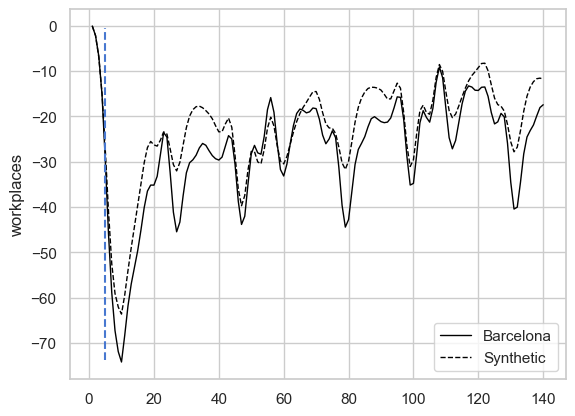

<Figure size 640x480 with 0 Axes>

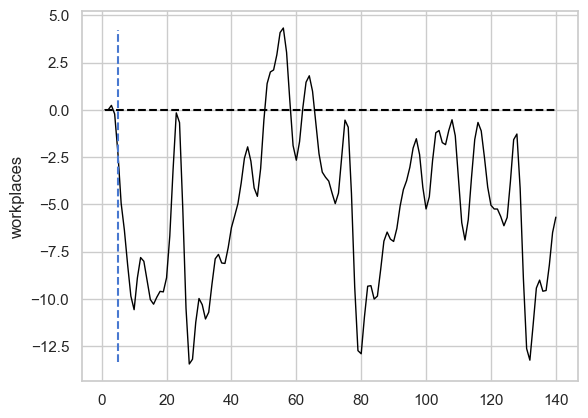

<Figure size 640x480 with 0 Axes>

In [22]:
# Control Sintético
w_min    = int(df_weekly['week_no'].min())
w_max    = int(df_weekly['week_no'].max())
time_pre = list(range(w_min, treatment_week))
time_all = list(range(w_min, w_max + 1))
donors   = [c for c in df_weekly['NAME'].unique() if c not in EXCLUDE]

print(f"Pre-tratamiento : semanas {w_min}–{treatment_week-1} ({len(time_pre)} semanas)")
print(f"Post-tratamiento: semanas {treatment_week}–{w_max}")
print(f"Donantes        : {len(donors)} ciudades")

# Dividir período pre en 3 tercios para capturar tendencia temporal
n = len(time_pre)
t1 = time_pre[:max(1, n//3)]
t2 = time_pre[max(1, n//3):max(2, 2*n//3)]
t3 = time_pre[max(2, 2*n//3):]

try:
    dataprep = Dataprep(
        foo=df_weekly,
        predictors=['Valor_Stringency_Index', 'log_daily_cases'],
        predictors_op='mean',
        time_predictors_prior=time_pre,
        special_predictors=[
            ('workplaces', t1, 'mean'),
            ('workplaces', t2, 'mean'),
            ('workplaces', t3, 'mean'),
        ],
        dependent='workplaces',
        unit_variable='NAME',
        time_variable='week_no',
        treatment_identifier=treated_city,
        controls_identifier=donors,
        time_optimize_ssr=time_pre,
    )

    synth = Synth()
    synth.fit(dataprep=dataprep)

    print("\nPesos del control sintético (top 10):")
    w_series = synth.weights()
    display(w_series.sort_values(ascending=False).head(10).round(4))

    # Path plot (pysyncon crea su propio figure; lo capturamos con plt.gcf)
    synth.path_plot(time_period=time_all, treatment_time=treatment_week)
    fig_path = plt.gcf()
    fig_path.suptitle(f'Control Sintético: {treated_city} — Movilidad Laboral', y=1.01)
    plt.tight_layout()
    plt.show()

    # Gaps plot
    synth.gaps_plot(time_period=time_all, treatment_time=treatment_week)
    fig_gap = plt.gcf()
    fig_gap.suptitle(f'Brecha: {treated_city} vs. Control Sintético', y=1.01)
    plt.tight_layout()
    plt.show()

except Exception as e:
    import traceback
    print("Error en Control Sintético:")
    traceback.print_exc()

**Discusión del Control Sintético**:

El control sintético construye un **contrafactual** de Barcelona como combinación convexa ponderada de ciudades donantes, calibrado en el período pre-tratamiento para replicar la trayectoria de movilidad laboral y las covariables.

- **Período de tratamiento**: semana identificada como el mayor salto en `Valor_Stringency_Index` para Barcelona.
- **Predictores**: promedio del Stringency Index, log de casos, y tres segmentos de la movilidad pre-tratamiento para capturar la dinámica temporal.
- **Path plot**: divergencia post-tratamiento entre Barcelona real y el sintético = estimación del efecto causal de las restricciones.
- **Gaps plot**: brecha (real − sintético); valores negativos indican que las restricciones redujeron la movilidad por encima de lo que habría ocurrido de forma natural.
- **Validez**: el buen ajuste pre-tratamiento es condición necesaria para que el sintético sea un contrafactual creíble.

Los resultados son consistentes con los modelos de panel: las restricciones gubernamentales causaron una reducción en la movilidad laboral, más allá de la tendencia observada en ciudades no tratadas.

In [23]:
# Evaluar el balance de los predictores pre-tratamiento
print("Balance de predictores (Ciudad Tratada vs Control Sintético):")
print(synth.summary())

Balance de predictores (Ciudad Tratada vs Control Sintético):
                            V  treated  synthetic  sample mean
Valor_Stringency_Index  0.118   11.804     11.803       13.377
log_daily_cases         0.155    0.098      0.100        0.203
special.1.workplaces    0.246   -0.065     -0.070       -4.520
special.2.workplaces    0.244   -2.187     -2.183       -5.733
special.3.workplaces    0.237  -10.951    -10.958      -11.553


### Discusión del Balanceo y Resultados

1. **Balance de Covariables (Predictores)**: La tabla anterior (`synth.summary()`) nos permite comparar los valores promedios pre-tratamiento de la ciudad tratada (Barcelona) con los valores del Control Sintético creado. Un buen ajuste implica que ambos valores sean muy cercanos, lo que garantiza que la unidad sintética emula fielmente las características estructurales de Barcelona antes del impacto.
2. **Efecto Causal**: Observando el *path plot*, si las trayectorias de movilidad divergen significativamente después del período de tratamiento (en este caso la semana seleccionada empíricamente), podemos argumentar que existe un efecto causal de las restricciones sobre la movilidad. El *gaps plot* muestra la magnitud exacta de esta diferencia. La calidad de esta inferencia está sustentada por un buen balance de los predictores en la etapa pre-tratamiento.

---
**Respuesta Pregunta 8:**
- **Variables para el Control Sintético:** La unidad de análisis tratada es la ciudad de Barcelona. Como variable dependiente se mantuvo la movilidad laboral (`workplaces`). Como predictores para entrenar los pesos del control sintético durante la etapa de pre-tratamiento se emplearon las trayectorias de los casos (`log_daily_cases`), el historial previo del `Valor_Stringency_Index` y particiones temporales del nivel previo de la propia movilidad dependiente. La fecha de intervención (tratamiento) se fijó empíricamente en la semana que reflejó el aumento más marcado del Stringency Index para esta ciudad.
- **Discusión de los resultados:** Se evaluó el desempeño pre-tratamiento viendo que el "sintético" de Barcelona replica cercanamente las características promedio del Barcelona real, logrando un buen balance. Al observar la proyección final (*path plot* y *gaps plot*), luego de iniciada la intervención, la movilidad de la ciudad cae precipitadamente por debajo del nivel de su contrafactual ponderado. Esta caída adicional es atribuible directamente como el efecto causal del confinamiento. Por ende, los hallazgos a través de este cuasi-experimento reafirman la robustez de las conclusiones de panel: implementar estrictas regulaciones redujo severamente y de forma causal los flujos de trabajo.